In [1]:
# a)

import random
import statistics

demands = [12,45,23,67,34,19,
           56,38,72,15,49,61,
           27,83,41,55,30,77,
           64,18,52,39,71,26,
           44,91,33,58,22,85,
           16,69,47,74,31,53]

GRID_SIZE = 6
DRIVERS = 10

def to_row_col(index):
    return (index // 6, index % 6)

def state_fitness(state):
    return sum(demands[i] for i in state) - 50

def random_state():
    return set(random.sample(range(36), 10))

def get_neighbors(state):
    neighbors = []
    outside = list(set(range(36)) - state)

    for s in state:
        for o in outside:
            new = set(state)
            new.remove(s)
            new.add(o)
            neighbors.append(new)

    return neighbors

print("===== PART (a) =====\n")

for i in range(3):
    s = random_state()
    print(f"State {i+1}: {sorted(s)}")
    print("Fitness:", state_fitness(s))
    print("Neighbors:", len(get_neighbors(s)))
    print()

# b)

def hc_driver(state, variant="stochastic"):
    current = state
    current_fit = state_fitness(current)
    steps = 0

    while True:
        neighbors = get_neighbors(current)

        if variant == "first":
            moved = False
            for n in neighbors:
                f = state_fitness(n)
                if f > current_fit:
                    current = n
                    current_fit = f
                    moved = True
                    steps += 1
                    break
            if not moved:
                break

        else:
            better = [n for n in neighbors if state_fitness(n) > current_fit]
            if not better:
                break
            current = random.choice(better)
            current_fit = state_fitness(current)
            steps += 1

    return current, current_fit, steps

def rrhc_driver(num_restarts):
    best = None
    best_fit = float('-inf')
    history = []

    for _ in range(num_restarts):
        start = random_state()
        final, fit, _ = hc_driver(start, "stochastic")

        history.append(fit)

        if fit > best_fit:
            best = final
            best_fit = fit

    return best, best_fit, history

print("\n===== PART (b) =====\n")

best, best_fit, history = rrhc_driver(30)

print("Best Fitness:", best_fit)
print("Best State:", sorted(best))

print("\nDriver Positions (row, col):")
for z in sorted(best):
    print(to_row_col(z), end=" ")
print()

print("\nFitness per restart:")
print(history)

# c)

def ga_fitness(chrom):
    return sum(demands[i] for i in chrom) - 50

def ordered_crossover(p1, p2):
    a, b = sorted(random.sample(range(10), 2))
    child = [None]*10

    child[a:b] = p1[a:b]

    fill = [x for x in p2 if x not in child]

    idx = 0
    for i in range(10):
        if child[i] is None:
            child[i] = fill[idx]
            idx += 1

    return sorted(child)

def ga_mutate(chrom, pm):
    if random.random() < pm:
        available = list(set(range(36)) - set(chrom))
        i = random.randint(0, 9)
        chrom[i] = random.choice(available)
    return sorted(chrom)

def tournament(pop):
    return max(random.sample(pop, 3), key=ga_fitness)

def run_ga(pop_size=30, generations=100, pm=0.1):
    pop = [sorted(random.sample(range(36), 10)) for _ in range(pop_size)]

    for _ in range(generations):
        new_pop = []

        while len(new_pop) < pop_size:
            p1 = tournament(pop)
            p2 = tournament(pop)

            child = ordered_crossover(p1, p2)
            child = ga_mutate(child, pm)

            new_pop.append(child)

        pop = new_pop

    best = max(pop, key=ga_fitness)
    return best, ga_fitness(best)

print("\n===== PART (c) =====\n")

best_ga, fit_ga = run_ga()

print("Best GA Fitness:", fit_ga)
print("Best Chromosome:", best_ga)

print("\nDriver Positions (row, col):")
for z in best_ga:
    print(to_row_col(z), end=" ")
print()

# d)

print("\n===== PART (d) =====\n")

hc_results = []
ga_results = []

for _ in range(20):
    _, fit_hc, _ = rrhc_driver(30)
    _, fit_ga = run_ga()

    hc_results.append(fit_hc)
    ga_results.append(fit_ga)

def summarize(name, data):
    print(f"{name}:")
    print("Mean:", round(statistics.mean(data), 2))
    print("Std:", round(statistics.stdev(data), 2))
    print("Best:", max(data))
    print()

summarize("RRHC", hc_results)
summarize("GA", ga_results)

===== PART (a) =====

State 1: [1, 3, 5, 6, 13, 15, 18, 27, 34, 35]
Fitness: 481
Neighbors: 260

State 2: [0, 2, 6, 12, 15, 18, 19, 20, 22, 31]
Fitness: 397
Neighbors: 260

State 3: [3, 4, 5, 8, 10, 14, 18, 30, 31, 34]
Fitness: 412
Neighbors: 260


===== PART (b) =====

Best Fitness: 703
Best State: [3, 8, 13, 17, 18, 22, 25, 29, 31, 33]

Driver Positions (row, col):
(0, 3) (1, 2) (2, 1) (2, 5) (3, 0) (3, 4) (4, 1) (4, 5) (5, 1) (5, 3) 

Fitness per restart:
[703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703, 703]

===== PART (c) =====

Best GA Fitness: 694
Best Chromosome: [8, 13, 17, 18, 22, 25, 27, 29, 31, 33]

Driver Positions (row, col):
(1, 2) (2, 1) (2, 5) (3, 0) (3, 4) (4, 1) (4, 3) (4, 5) (5, 1) (5, 3) 

===== PART (d) =====

RRHC:
Mean: 703
Std: 0.0
Best: 703

GA:
Mean: 695.2
Std: 7.41
Best: 703



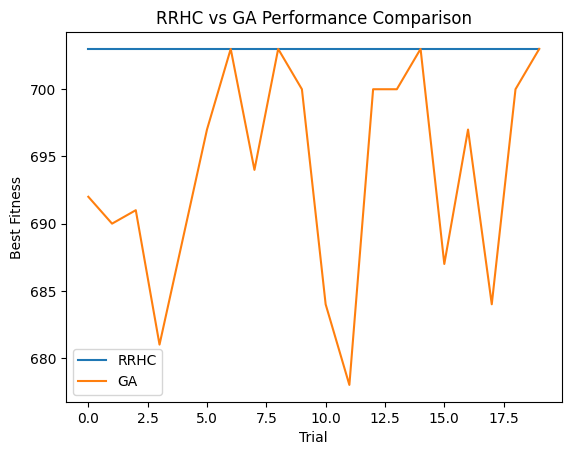

In [2]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(hc_results, label="RRHC")
plt.plot(ga_results, label="GA")

plt.xlabel("Trial")
plt.ylabel("Best Fitness")
plt.title("RRHC vs GA Performance Comparison")

plt.legend()
plt.show()